CREATING NEW FEATURES

In [2]:
import pandas as pd
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df[['SibSp','Parch']].head()

,SibSp,Parch
0,1,0
1,1,0
2,0,0
3,1,0
4,0,0


In [4]:
df['Family_Size']=df['SibSp']+df['Parch']+1

In [5]:
df[['SibSp','Parch','Family_Size']].head()

,SibSp,Parch,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [6]:
df['Is_Alone']=(df['Family_Size']==1).astype(int)


In [7]:
df['Is_Alone'].sum()

np.int64(537)

In [8]:
df['Family_Size'].value_counts().sort_index()

Family_Size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [9]:
df.groupby('Is_Alone')['Survived'].sum()

Is_Alone
0    179
1    163
Name: Survived, dtype: int64

In [10]:
df['Survived'].sum()

np.int64(342)

In [11]:
df.groupby('Is_Alone')['Survived'].mean()*100

Is_Alone
0    50.564972
1    30.353818
Name: Survived, dtype: float64

In [12]:
df['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str

In [13]:
df['Title']=df['Name'].str.extract(r',\s([^\.]+)\.')
df['Title'].value_counts()



Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [14]:
df.groupby('Title')['Survived'].sum().sort_values(ascending=False)

Title
Miss            127
Mrs              99
Mr               81
Master           23
Dr                3
Mlle              2
Ms                1
Major             1
Col               1
the Countess      1
Sir               1
Lady              1
Mme               1
Capt              0
Jonkheer          0
Don               0
Rev               0
Name: Survived, dtype: int64

In [15]:
df.groupby('Title')['Survived'].mean()*100

Title
Capt              0.000000
Col              50.000000
Don               0.000000
Dr               42.857143
Jonkheer          0.000000
Lady            100.000000
Major            50.000000
Master           57.500000
Miss             69.780220
Mlle            100.000000
Mme             100.000000
Mr               15.667311
Mrs              79.200000
Ms              100.000000
Rev               0.000000
Sir             100.000000
the Countess    100.000000
Name: Survived, dtype: float64

In [16]:
df.groupby('Title').agg(Total=('Survived','count'),
                                Survived=('Survived','sum'),
                                Survival_rate=('Survived','mean')).sort_values('Total',ascending=False)

,Total,Survived,Survival_rate
Title,,,
Mr,517,81,0.156673
Miss,182,127,0.697802
Mrs,125,99,0.792000
Master,40,23,0.575000
Dr,7,3,0.428571
Rev,6,0,0.000000
Mlle,2,2,1.000000
Major,2,1,0.500000
Col,2,1,0.500000


In [17]:
Survival_Rate=df.groupby('Title')['Survived'].mean().sort_values(ascending=False)

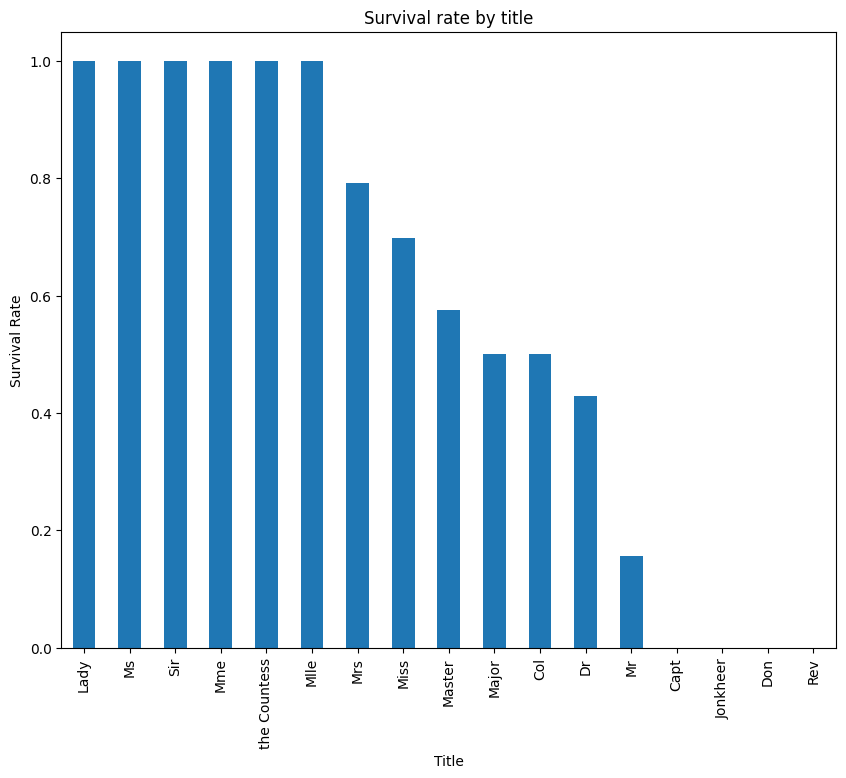

In [18]:
import matplotlib.pyplot as plt

Survival_Rate.plot(kind='bar',figsize=(10,8))
plt.title("Survival rate by title")
plt.xlabel("Title")
plt.ylabel("Survival Rate")

plt.show()

In [19]:
Rare_titles=['Mlle','Major','Col','Capt','Lady','Don','Jonkheer','Mme','Ms','Sir','the Countess']
df['Title_Grouped']=df['Title'].replace(Rare_titles,'Rare')

In [20]:
df['Title_Grouped'].value_counts()

Title_Grouped
Mr        517
Miss      182
Mrs       125
Master     40
Rare       14
Dr          7
Rev         6
Name: count, dtype: int64

In [21]:
df.groupby('Title_Grouped').agg(Total=("Survived",'count'),
                                                Survived=("Survived",'sum'),
                                                Survival_Rate=("Survived",'mean')).sort_values('Survival_Rate',ascending=False)

,Total,Survived,Survival_Rate
Title_Grouped,,,
Mrs,125,99,0.792000
Miss,182,127,0.697802
Rare,14,9,0.642857
Master,40,23,0.575000
Dr,7,3,0.428571
Mr,517,81,0.156673
Rev,6,0,0.000000


In [22]:
Survival_Rate=df.groupby('Title_Grouped')['Survived'].mean().sort_values(ascending=False)

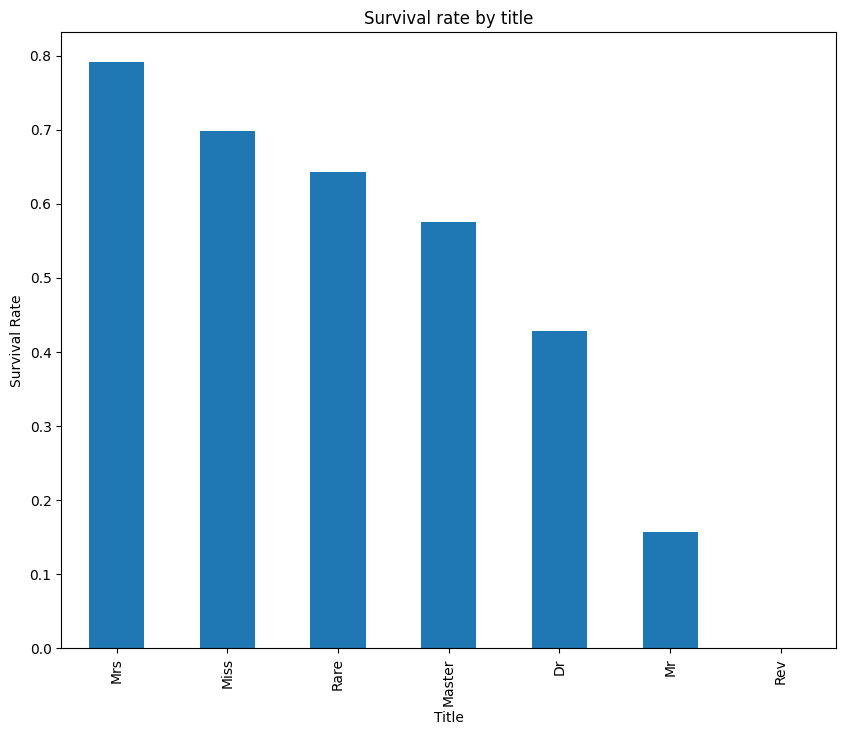

In [23]:
import matplotlib.pyplot as plt
Survival_Rate.plot(kind='bar',figsize=(10,8))
plt.title("Survival rate by title")
plt.xlabel("Title")
plt.ylabel("Survival Rate")

plt.show()

TRANFORMATION

A) BINNING

In [24]:
import pandas as pd
df=pd.read_csv('train.csv')

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:
df['Age'].isnull().sum()

np.int64(177)

In [26]:
df['Age']=df["Age"].fillna(df["Age"].mean())

In [27]:
df['Age'].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [28]:
bins=[0,12,19,50,80]
labels=['Child','Teen','Adult','Senior']

df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)

df[['Age','Age_Group']].head(10)

,Age,Age_Group
0,22.000000,Adult
1,38.000000,Adult
2,26.000000,Adult
3,35.000000,Adult
4,35.000000,Adult
5,29.699118,Adult
6,54.000000,Senior
7,2.000000,Child
8,27.000000,Adult
9,14.000000,Teen


In [29]:
df["Age_Group"].value_counts()

Age_Group
Adult     663
Teen       95
Child      69
Senior     64
Name: count, dtype: int64

In [30]:
df.groupby('Age_Group')['Survived'].mean()

Age_Group
Child     0.579710
Teen      0.410526
Adult     0.363499
Senior    0.343750
Name: Survived, dtype: float64

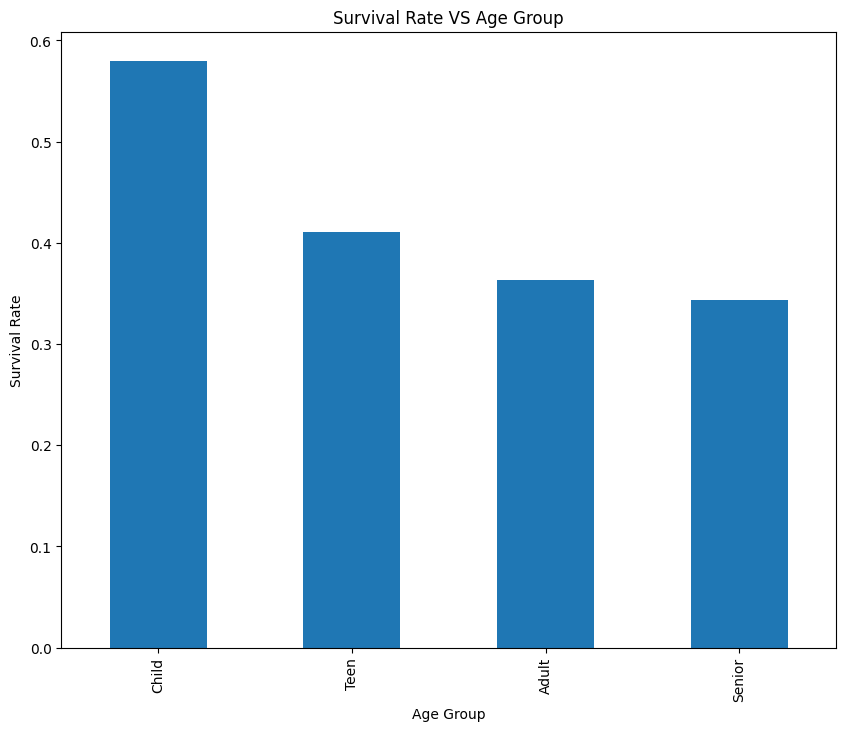

In [31]:
Survival_Rate=df.groupby('Age_Group')['Survived'].mean()

import matplotlib.pyplot as plt
Survival_Rate.plot(kind='bar',figsize=(10,8))
plt.title("Survival Rate VS Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

B) POLYNOMIAL TRANSFORMATION

In [32]:
X=df[['Age','Fare']]

In [33]:
X['Age']=X['Age'].fillna(X["Age"].mean())

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
X_Poly=poly.fit_transform(X)
print(poly.get_feature_names_out())

['1' 'Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [35]:
import pandas as pd

X_poly_df=pd.DataFrame(X_Poly,columns=poly.get_feature_names_out())
X_poly_df.head()

,1,Age,Fare,Age^2,Age Fare,Fare^2
0,1.0,22.0,7.2500,484.0,159.5000,52.562500
1,1.0,38.0,71.2833,1444.0,2708.7654,5081.308859
2,1.0,26.0,7.9250,676.0,206.0500,62.805625
3,1.0,35.0,53.1000,1225.0,1858.5000,2819.610000
4,1.0,35.0,8.0500,1225.0,281.7500,64.802500


C) ENCODING CATEGORICAL DATA

1) ORDINAL ENCODING

In [36]:
import pandas as pd
df_edu=pd.DataFrame({'Education':['High School','Bachelor','Master','Phd','Bachelor','Master','High School']})
df_edu

,Education
0,High School
1,Bachelor
2,Master
3,Phd
4,Bachelor
5,Master
6,High School


In [37]:
education_order={'High School':0,
                 'Bachelor':1,
                 'Master':2,
                 'Phd':3}

df_edu['Education_Encoded']=df_edu['Education'].map(education_order)

df_edu

,Education,Education_Encoded
0,High School,0
1,Bachelor,1
2,Master,2
3,Phd,3
4,Bachelor,1
5,Master,2
6,High School,0


In [38]:
import pandas as pd

df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
df.select_dtypes(include='object').head()

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_22028\3294020596.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').head()


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


In [40]:
#NOTE: None the categorical data have a natural order
#Pclass is already encoded.
df['Pclass'].head()

0    3
1    1
2    3
3    1
4    3
Name: Pclass, dtype: int64

In [41]:
import pandas as pd
df=pd.read_csv('datascience.csv')

df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.9 MB


In [43]:
df.describe(include='object')

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_22028\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type
count,19158,14650,19158,18772,18698,16345,13220,13018
unique,123,3,2,3,5,6,8,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,50-99,Pvt Ltd
freq,4355,13221,13792,13817,11598,14492,3083,9817


In [44]:
df.select_dtypes(include='object').columns

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_22028\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'company_size', 'company_type'],
      dtype='str')

In [45]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   21
company_size                  8
company_type                  6
training_hours              241
target                        2
dtype: int64

In [46]:
df.shape

(19158, 13)

In [47]:
df['education_level'].sample(5)

687      Masters
4786    Graduate
1523    Graduate
888     Graduate
6798    Graduate
Name: education_level, dtype: str

In [48]:
df['education_level'].value_counts(dropna=False)


education_level
Graduate          11598
Masters            4361
High School        2017
NaN                 460
Phd                 414
Primary School      308
Name: count, dtype: int64

In [49]:
df['education_level']=df['education_level'].fillna('Unknown')

In [50]:
df['education_level'].unique()

<StringArray>
['Graduate', 'Masters', 'High School', 'Unknown', 'Phd', 'Primary School']
Length: 6, dtype: str

In [51]:
education_order=['Unknown','Primary School','High School','Graduate','Masters','Phd']
from sklearn.preprocessing import OrdinalEncoder

encoder=OrdinalEncoder(categories=[education_order])

In [52]:
df['education_level_encoded']=encoder.fit_transform(df[['education_level']])

In [53]:
df[['education_level','education_level_encoded']]

,education_level,education_level_encoded
0,Graduate,3.0
1,Graduate,3.0
2,Graduate,3.0
3,Graduate,3.0
4,Masters,4.0
...,...,...
19153,Graduate,3.0
19154,Graduate,3.0
19155,Graduate,3.0
19156,High School,2.0


D)BINARY CATEGORICAL DATA

1) LABEL ENCODING

In [54]:
import pandas as pd

df=pd.read_csv('datascience.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.9 MB


In [55]:
df['gender'].unique()

<StringArray>
['Male', nan, 'Female', 'Other']
Length: 4, dtype: str

In [56]:
df.nunique(dropna=False)

enrollee_id               19158
city                        123
city_development_index       94
gender                        4
relevent_experience           2
enrolled_university           4
education_level               6
major_discipline              7
experience                   22
company_size                  9
company_type                  7
training_hours              242
target                        2
dtype: int64

In [57]:
df['relevent_experience'].unique()

<StringArray>
['Has relevent experience', 'No relevent experience']
Length: 2, dtype: str

In [58]:
df['target'].unique()

array([1., 0.])

In [59]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['relevent_experience_encoded']=le.fit_transform(df['relevent_experience'])

In [60]:
df[['relevent_experience','relevent_experience_encoded']].head()

,relevent_experience,relevent_experience_encoded
0,Has relevent experience,0
1,No relevent experience,1
2,No relevent experience,1
3,No relevent experience,1
4,Has relevent experience,0


E) NOMINAL CATEGORICAL DATA

1) ONE-HOT ENCODING

In [61]:
import pandas as pd
df=pd.read_csv('datascience.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.9 MB


In [62]:
df.shape

(19158, 13)

In [63]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   21
company_size                  8
company_type                  6
training_hours              241
target                        2
dtype: int64

In [64]:
df['major_discipline'].unique()

<StringArray>
['STEM', 'Business Degree', nan, 'Arts', 'Humanities', 'No Major', 'Other']
Length: 7, dtype: str

In [65]:
df['major_discipline']=df['major_discipline'].fillna('Unknown')

In [66]:
df['major_discipline'].unique()

<StringArray>
['STEM', 'Business Degree', 'Unknown', 'Arts', 'Humanities', 'No Major',
 'Other']
Length: 7, dtype: str

In [67]:
from sklearn.preprocessing import OneHotEncoder

oh=OneHotEncoder(sparse_output=False)

encoded=oh.fit_transform(df[['major_discipline']])
encoded.shape

(19158, 7)

In [68]:
oh.get_feature_names_out()

array(['major_discipline_Arts', 'major_discipline_Business Degree',
       'major_discipline_Humanities', 'major_discipline_No Major',
       'major_discipline_Other', 'major_discipline_STEM',
       'major_discipline_Unknown'], dtype=object)

In [1]:
encoded_df=pd.DataFrame(encoded,columns=oh.get_feature_names_out())
encoded_df

NameError: name 'pd' is not defined